# Optimización: Gradiente Descendente y Newton-Raphson

**Simulaciones y Procesos Estocásticos — UCA 2026**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

## 1. Visualización de la función de pérdida

Vamos a trabajar primero en 1D y luego en 2D para desarrollar la intuición geométrica.

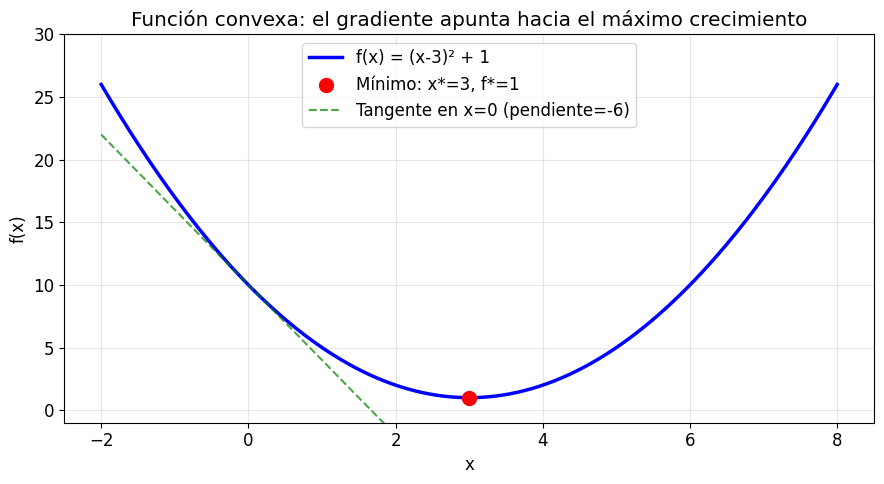

In [2]:
# Función convexa simple en 1D: f(x) = (x-3)^2 + 1
def f1d(x): return (x - 3)**2 + 1
def df1d(x): return 2*(x - 3)  # gradiente
def d2f1d(x): return 2.0        # segunda derivada (Hessiana en 1D)

x_grid = np.linspace(-2, 8, 300)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x_grid, f1d(x_grid), 'b-', lw=2.5, label='f(x) = (x-3)² + 1')
ax.scatter([3], [1], color='red', s=100, zorder=5, label='Mínimo: x*=3, f*=1')
# Tangente en x=0
x0 = 0
tang = f1d(x0) + df1d(x0) * (x_grid - x0)
ax.plot(x_grid, tang, 'g--', alpha=0.7, label=f'Tangente en x={x0} (pendiente={df1d(x0):.0f})')
ax.set_ylim(-1, 30)
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title('Función convexa: el gradiente apunta hacia el máximo crecimiento')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Gradiente Descendente en 1D

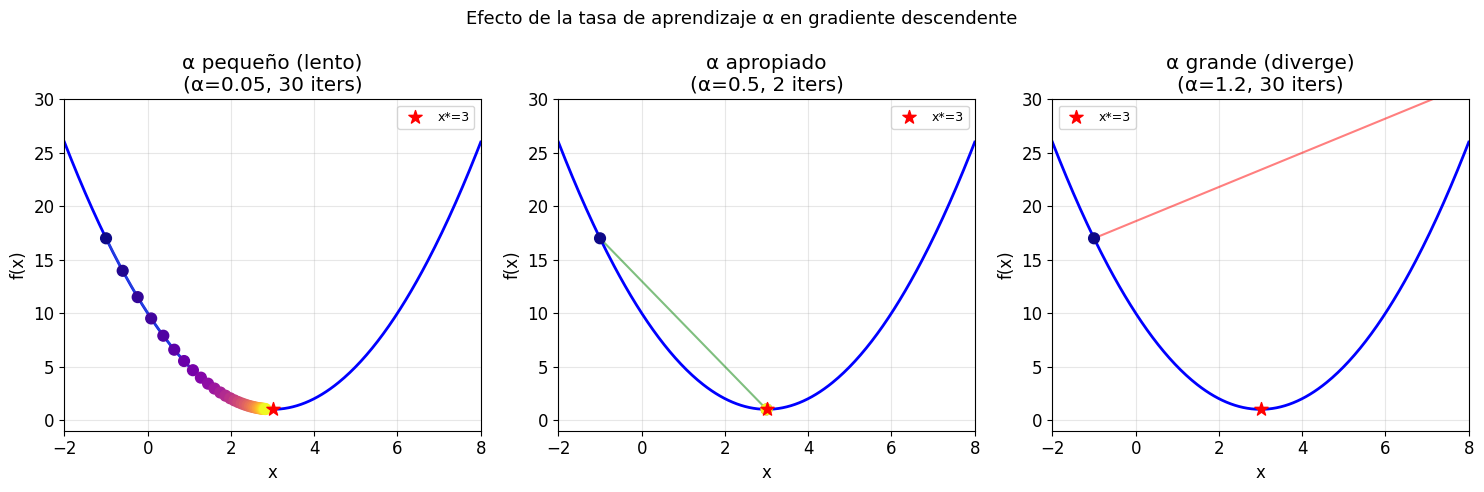

In [3]:
def gradient_descent_1d(f, df, x0, alpha, max_iter=50, tol=1e-8):
    """Gradiente descendente en 1D. Devuelve historia de iteraciones."""
    historia = [x0]
    x = x0
    for _ in range(max_iter):
        x_new = x - alpha * df(x)
        historia.append(x_new)
        if abs(x_new - x) < tol:
            break
        x = x_new
    return np.array(historia)

x0 = -1.0  # punto de inicio

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
alphas = [0.05, 0.5, 1.2]  # pequeño, bueno, demasiado grande
etiquetas = ['α pequeño (lento)', 'α apropiado', 'α grande (diverge)']
colores_tray = ['steelblue', 'green', 'red']

for ax, alpha, etiqueta, color in zip(axes, alphas, etiquetas, colores_tray):
    historia = gradient_descent_1d(f1d, df1d, x0, alpha, max_iter=30)
    historia_f = f1d(historia)
    
    ax.plot(x_grid, f1d(x_grid), 'b-', lw=2)
    ax.scatter(historia, historia_f, c=range(len(historia)), 
               cmap='plasma', s=60, zorder=5)
    ax.plot(historia, historia_f, color=color, alpha=0.5, lw=1.5)
    ax.scatter([3], [1], color='red', s=100, marker='*', zorder=6, label='x*=3')
    ax.set_title(f'{etiqueta}\n(α={alpha}, {len(historia)-1} iters)')
    ax.set_xlabel('x'); ax.set_ylabel('f(x)')
    ax.set_ylim(-1, 30); ax.set_xlim(-2, 8)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Efecto de la tasa de aprendizaje α en gradiente descendente', fontsize=13)
plt.tight_layout()
plt.show()

## 3. Gradiente Descendente en 2D: visualización de contornos

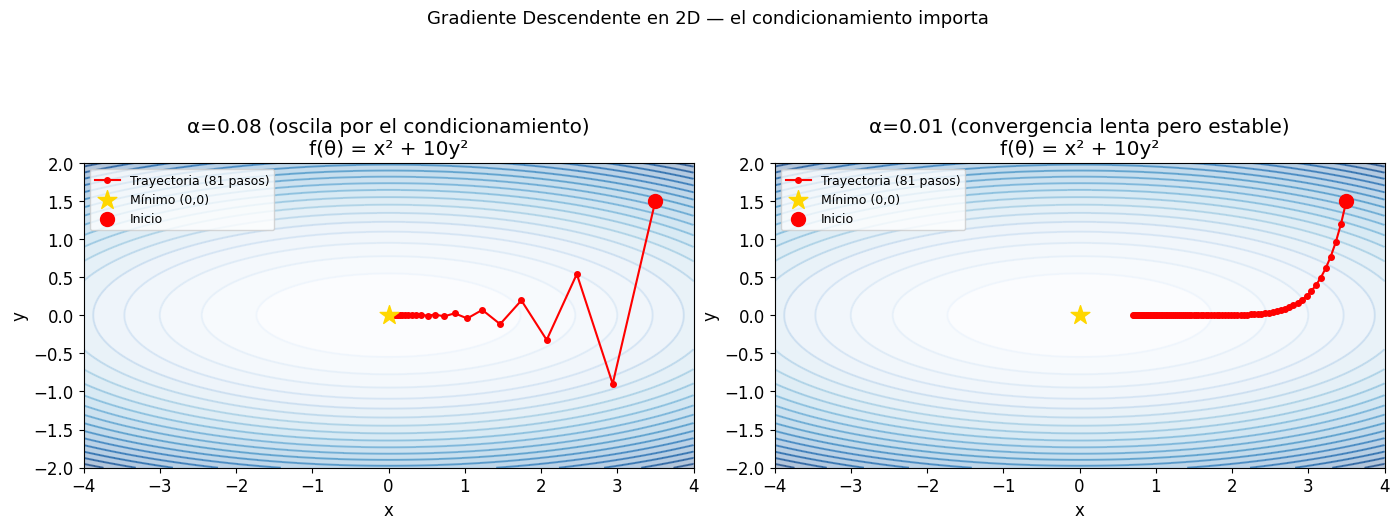

In [4]:
# Función elíptica (condicionamiento malo para ilustrar zigzag)
# f(x,y) = x^2 + 10*y^2
def f2d(theta):
    x, y = theta
    return x**2 + 10 * y**2

def grad_f2d(theta):
    x, y = theta
    return np.array([2*x, 20*y])

def gd_2d(f, grad_f, theta0, alpha, max_iter=100):
    historia = [theta0.copy()]
    theta = theta0.copy()
    for _ in range(max_iter):
        theta = theta - alpha * grad_f(theta)
        historia.append(theta.copy())
    return np.array(historia)

# Grilla para contornos
X_g = np.linspace(-4, 4, 200)
Y_g = np.linspace(-2, 2, 200)
XX, YY = np.meshgrid(X_g, Y_g)
ZZ = XX**2 + 10 * YY**2

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
theta0 = np.array([3.5, 1.5])

for ax, alpha, titulo in zip(axes, [0.08, 0.01], 
                              ['α=0.08 (oscila por el condicionamiento)', 
                               'α=0.01 (convergencia lenta pero estable)']):
    hist = gd_2d(f2d, grad_f2d, theta0, alpha, max_iter=80)
    
    ax.contour(XX, YY, ZZ, levels=20, cmap='Blues', alpha=0.6)
    ax.contourf(XX, YY, ZZ, levels=20, cmap='Blues', alpha=0.3)
    ax.plot(hist[:,0], hist[:,1], 'o-', color='red', ms=4, lw=1.5,
            label=f'Trayectoria ({len(hist)} pasos)')
    ax.scatter([0], [0], color='gold', s=200, marker='*', zorder=5, label='Mínimo (0,0)')
    ax.scatter([theta0[0]], [theta0[1]], color='red', s=100, zorder=5, label='Inicio')
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.set_title(f'{titulo}\nf(θ) = x² + 10y²')
    ax.legend(fontsize=9)
    ax.set_aspect('equal')
    
plt.suptitle('Gradiente Descendente en 2D — el condicionamiento importa', fontsize=13)
plt.tight_layout()
plt.show()

## 4. SGD vs Batch GD: el efecto del ruido

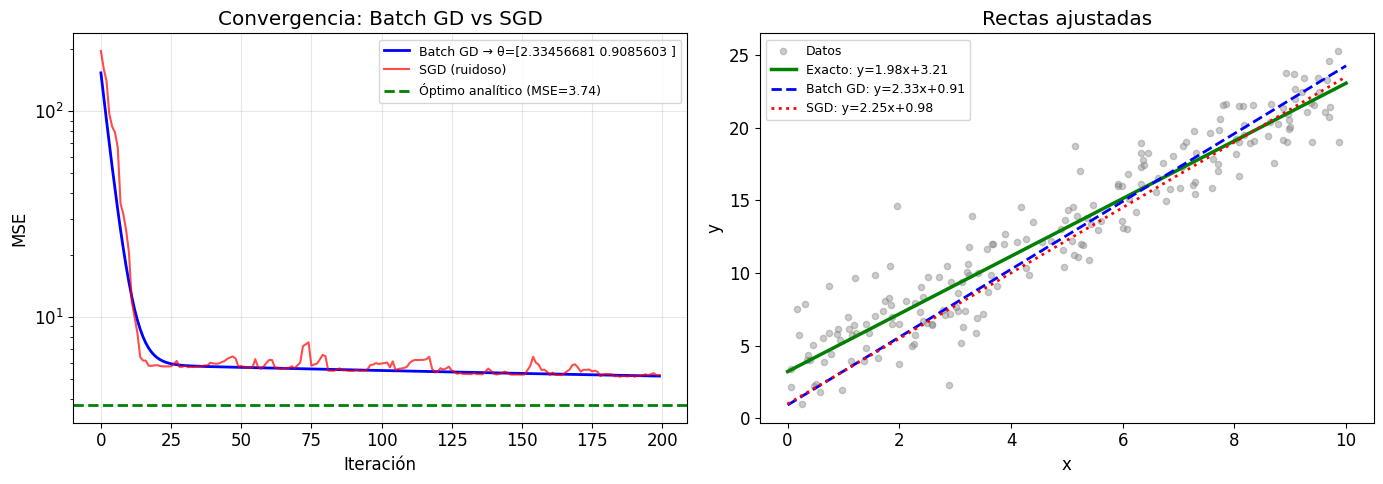

In [ ]:
# Regresión lineal: minimizar MSE
# Generamos datos: y = 2x + 3 + ruido
n_datos = 200
X_data = np.random.uniform(0, 10, n_datos)
y_data = 2 * X_data + 3 + np.random.normal(0, 2, n_datos)

# L = sum_i (y_i - (w*x_i + b))^2
def mse(theta, X, y):
    w, b = theta
    pred = w * X + b
    return np.mean((pred - y)**2)

# dL/dw = -2 * sum_i (y_i - (w*x_i + b)) * x_i
# dL/db = -2 * sum_i (y_i - (w*x_i + b))
# gradiente = [dL/dw, dL/db]
def grad_mse(theta, X, y):
    w, b = theta
    pred = w * X + b
    dw = 2 * np.mean((pred - y) * X)
    db = 2 * np.mean(pred - y)
    return np.array([dw, db])

# Batch GD: Lo que vimos, GD sobre TODO el dataset en cada iteración
theta_batch = np.array([0.0, 0.0])
loss_batch = []
alpha = 0.002
for _ in range(200):
    g = grad_mse(theta_batch, X_data, y_data)
    theta_batch = theta_batch - alpha * g
    loss_batch.append(mse(theta_batch, X_data, y_data))

# SGD: divido el dataset en mini-batches (en este caso, batch de tamaño 1)
# Luego hago GD sobre ese mini-batch en cada iteración
# Una época es cuando he pasado por todo el dataset (n_epochs: en este caso, 200 iteraciones)
theta_sgd = np.array([0.0, 0.0])
loss_sgd = []
alpha_sgd = 0.002
n_epochs = 200
for epoch in range(n_epochs):
    idx = np.random.randint(n_datos)
    xi, yi = X_data[idx:idx+1], y_data[idx:idx+1]
    g = grad_mse(theta_sgd, xi, yi)
    theta_sgd = theta_sgd - alpha_sgd * g
    loss_sgd.append(mse(theta_sgd, X_data, y_data))

# Solución analítica
A = np.column_stack([X_data, np.ones(n_datos)])
theta_exacto, _, _, _ = np.linalg.lstsq(A, y_data, rcond=None)
loss_exacto = mse(theta_exacto, X_data, y_data)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(loss_batch, 'b-', lw=2, label=f'Batch GD → θ={theta_batch}')
ax.plot(loss_sgd, 'r-', alpha=0.7, lw=1.5, label=f'SGD (ruidoso)')
ax.axhline(loss_exacto, color='green', ls='--', lw=2, label=f'Óptimo analítico (MSE={loss_exacto:.2f})')
ax.set_xlabel('Iteración'); ax.set_ylabel('MSE')
ax.set_title('Convergencia: Batch GD vs SGD')
ax.legend(fontsize=9)
ax.set_yscale('log')
ax.grid(True, alpha=0.3)

ax = axes[1]
x_plot = np.linspace(0, 10, 100)
ax.scatter(X_data, y_data, alpha=0.4, s=20, color='gray', label='Datos')
ax.plot(x_plot, theta_exacto[0]*x_plot + theta_exacto[1], 'g-', lw=2.5, 
        label=f'Exacto: y={theta_exacto[0]:.2f}x+{theta_exacto[1]:.2f}')
ax.plot(x_plot, theta_batch[0]*x_plot + theta_batch[1], 'b--', lw=2, 
        label=f'Batch GD: y={theta_batch[0]:.2f}x+{theta_batch[1]:.2f}')
ax.plot(x_plot, theta_sgd[0]*x_plot + theta_sgd[1], 'r:', lw=2, 
        label=f'SGD: y={theta_sgd[0]:.2f}x+{theta_sgd[1]:.2f}')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Rectas ajustadas')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 5. Método de Newton-Raphson

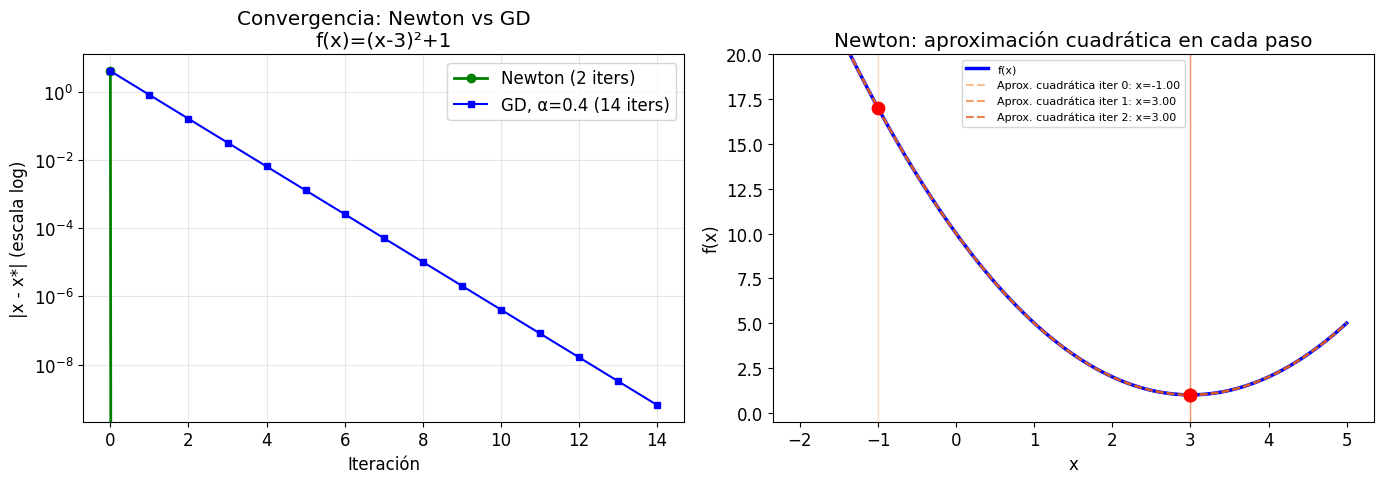

Newton: llega al mínimo en 2 iteraciones (función cuadrática → 1 paso exacto)
GD:     llega al mínimo en 14 iteraciones


In [6]:
def newton_raphson_1d(f, df, d2f, x0, max_iter=20, tol=1e-10):
    """Newton-Raphson para optimización en 1D."""
    historia = [x0]
    x = x0
    for _ in range(max_iter):
        # Paso de Newton: x <- x - f'(x)/f''(x)
        x_new = x - df(x) / d2f(x)
        historia.append(x_new)
        if abs(x_new - x) < tol:
            break
        x = x_new
    return np.array(historia)

# Comparar convergencia: Newton vs GD en función cuadrática (1D)
x0_comp = -1.0
hist_newton = newton_raphson_1d(f1d, df1d, d2f1d, x0_comp)
hist_gd = gradient_descent_1d(f1d, df1d, x0_comp, alpha=0.4, max_iter=50)

errores_newton = np.abs(hist_newton - 3.0)
errores_gd = np.abs(hist_gd - 3.0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.semilogy(errores_newton, 'g-o', ms=6, lw=2, label=f'Newton ({len(hist_newton)-1} iters)')
ax.semilogy(errores_gd, 'b-s', ms=4, lw=1.5, label=f'GD, α=0.4 ({len(hist_gd)-1} iters)')
ax.set_xlabel('Iteración'); ax.set_ylabel('|x - x*| (escala log)')
ax.set_title('Convergencia: Newton vs GD\nf(x)=(x-3)²+1')
ax.legend()
ax.grid(True, alpha=0.3)

# Visualizar pasos de Newton con aproximación cuadrática
ax = axes[1]
x_g = np.linspace(-2, 5, 300)
ax.plot(x_g, f1d(x_g), 'b-', lw=2.5, label='f(x)')

colores_newton = plt.cm.Oranges(np.linspace(0.4, 0.9, 4))
for i, (xk, col) in enumerate(zip(hist_newton[:4], colores_newton)):
    # Aproximación cuadrática en xk
    quad = f1d(xk) + df1d(xk)*(x_g - xk) + 0.5*d2f1d(xk)*(x_g - xk)**2
    ax.plot(x_g, quad, '--', color=col, alpha=0.7, lw=1.5,
            label=f'Aprox. cuadrática iter {i}: x={xk:.2f}')
    ax.axvline(xk, color=col, alpha=0.4, lw=1)

ax.scatter(hist_newton[:4], f1d(np.array(hist_newton[:4])), 
           s=80, color='red', zorder=5)
ax.set_ylim(-0.5, 20)
ax.set_xlabel('x'); ax.set_ylabel('f(x)')
ax.set_title('Newton: aproximación cuadrática en cada paso')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"Newton: llega al mínimo en {len(hist_newton)-1} iteraciones (función cuadrática → 1 paso exacto)")
print(f"GD:     llega al mínimo en {len(hist_gd)-1} iteraciones")

Para L(θ) = (1/2n)||Xθ − y||² :

- ∇L(θ) = (1/n) Xᵀ(Xθ − y)
- H_L(θ) = (1/n) XᵀX (constante, independiente de θ)
- Solución exacta: θ* = (XᵀX)⁻¹Xᵀy

**Demostración:** Newton llega a la solución exacta en 1 solo paso (porque L es cuadrática).
SGD llega iterativamente. Visualizar ambas trayectorias.


## 6. Funciones no convexas: el problema de los mínimos locales

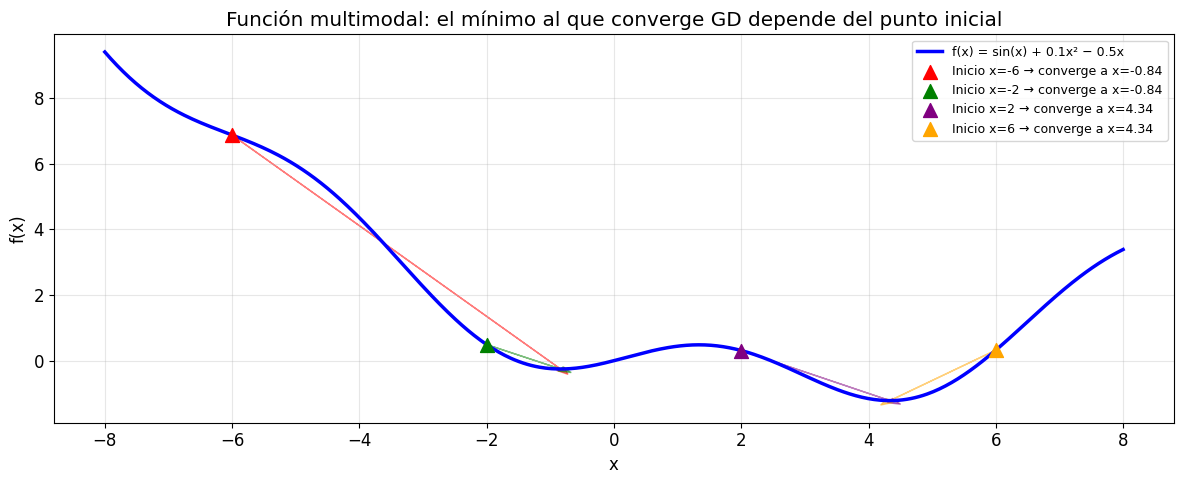

→ Misma función, misma α, distintos x0 → distintos mínimos locales
→ Para este tipo de problema: metaheurísticas


In [ ]:
# Función multimodal
def f_multi(x): return np.sin(x) + 0.1*x**2 - 0.5*x
def df_multi(x): return np.cos(x) + 0.2*x - 0.5

x_g = np.linspace(-8, 8, 500)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(x_g, f_multi(x_g), 'b-', lw=2.5, label='f(x) = sin(x) + 0.1x² − 0.5x')

colores_start = ['red', 'green', 'purple', 'orange']
starts = [-6, -2, 2, 6]

for x0_m, col in zip(starts, colores_start):
    hist = gradient_descent_1d(f_multi, df_multi, x0_m, alpha=0.1, max_iter=200)
    ax.scatter([x0_m], [f_multi(x0_m)], color=col, s=100, zorder=5, 
               marker='^', label=f'Inicio x={x0_m} → converge a x={hist[-1]:.2f}')
    ax.arrow(x0_m, f_multi(x0_m), hist[-1]-x0_m, f_multi(hist[-1])-f_multi(x0_m),
             head_width=0.15, head_length=0.2, color=col, alpha=0.5)

ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title('Función multimodal: el mínimo al que converge GD depende del punto inicial')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("→ Misma función, mismo α, distintos x0 → distintos mínimos locales")
print("→ Para este tipo de problema: metaheurísticas")

## Resumen

- **Gradiente Descendente**: θ ← θ − α∇f(θ). Simple, escalable. Convergencia lineal.
- **Learning rate α**: crítico. Demasiado pequeño → lento. Demasiado grande → diverge.
- **SGD**: un ejemplo (o mini-batch) por iteración. Ruidoso pero más rápido en datos grandes.
- **Newton**: usa f''(x) (Hessiana). Convergencia cuadrática. Caro para d grande.
- **Funciones no convexas**: GD converge a mínimos locales; la elección de x₀ importa.